In [1]:
import tensorflow as tf
import numpy as np
import cv2
import os
import random
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
train_dir = "C:/Users/HP/Downloads/dl_fa2/dataset/train"
test_dir = "C:/Users/HP/Downloads/dl_fa2/dataset/test"

img_size = 48
batch_size = 64

In [3]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 45304 images belonging to 7 classes.
Found 6286 images belonging to 7 classes.


In [4]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    zoom_range=0.3,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2]
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(48,48),
    color_mode='grayscale',
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 45304 images belonging to 7 classes.
Found 6286 images belonging to 7 classes.


In [5]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_data.classes),
    y=train_data.classes
)

class_weights = dict(enumerate(class_weights))

In [6]:
model = Sequential([
    tf.keras.Input(shape=(48,48,1)),

    Conv2D(64, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(256, (3,3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D(2,2),

    Conv2D(512, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(512, activation='relu'),
    Dropout(0.5),

    Dense(7, activation='softmax')
])

In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=6,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-6
)

In [9]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=40,
    callbacks=[early_stop, reduce_lr],
    class_weight=class_weights
)

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/40
708/708 ━━━━━━━━━━━━━━━━━━━━ 320s 445ms/step - accuracy: 0.1997 - loss: 1.9499 - val_accuracy: 0.2809 - val_loss: 1.7992 - learning_rate: 3.0000e-04
Epoch 2/40
708/708 ━━━━━━━━━━━━━━━━━━━━ 283s 399ms/step - accuracy: 0.2757 - loss: 1.8099 - val_accuracy: 0.3828 - val_loss: 1.6254 - learning_rate: 3.0000e-04
Epoch 3/40
708/708 ━━━━━━━━━━━━━━━━━━━━ 291s 411ms/step - accuracy: 0.3455 - loss: 1.6829 - val_accuracy: 0.4297 - val_loss: 1.4941 - learning_rate: 3.0000e-04
Epoch 4/40
708/708 ━━━━━━━━━━━━━━━━━━━━ 550s 777ms/step - accuracy: 0.3970 - loss: 1.5676 - val_accuracy: 0.4623 - val_loss: 1.4219 - learning_rate: 3.0000e-04
Epoch 5/40
708/708 ━━━━━━━━━━━━━━━━━━━━ 304s 430ms/step - accuracy: 0.4281 - loss: 1.4969 - val_accuracy: 0.4443 - val_loss: 1.4346 - learning_rate: 3.0000e-04
Epoch 6/40
708/708 ━━━━━━━━━━━━━━━━━━━━ 336s 475ms/step - accuracy: 0.4486 - loss: 1.4428 - val_accuracy: 0.5204 - val_loss: 1.2646 - learning_rate: 3.0000e-04
Epoch 7/40
708/708 ━━━━━━━━━━━━━━━━━━━━ 

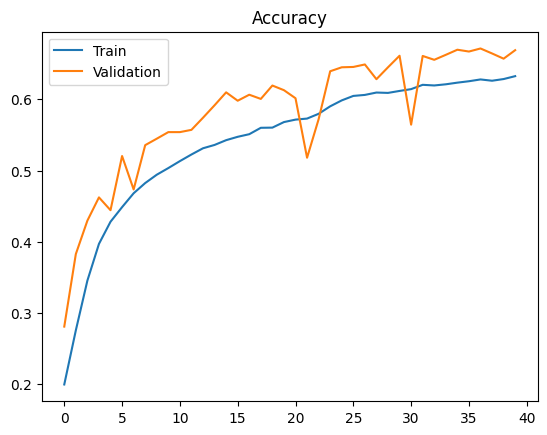

In [10]:
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy")
plt.show()

In [11]:
Y_pred = model.predict(test_data)
y_pred = np.argmax(Y_pred, axis=1)

cm = confusion_matrix(test_data.classes, y_pred)
print(cm)

print("\nClassification Report:\n")
print(classification_report(test_data.classes, y_pred, target_names=test_data.class_indices.keys()))

99/99 ━━━━━━━━━━━━━━━━━━━━ 17s 154ms/step
[[560  46  63  18 109  74  28]
 [ 10 887   1   0   0   0   0]
 [146  31 339  21 108 110 143]
 [ 39   9  22 703  64  26  35]
 [ 85  12  49  35 587 101  29]
 [131  23 134  22 197 368  23]
 [ 21   3  61  17  28   7 761]]

Classification Report:

              precision    recall  f1-score   support

       angry       0.56      0.62      0.59       898
     disgust       0.88      0.99      0.93       898
        fear       0.51      0.38      0.43       898
       happy       0.86      0.78      0.82       898
     neutral       0.54      0.65      0.59       898
         sad       0.54      0.41      0.46       898
    surprise       0.75      0.85      0.79       898

    accuracy                           0.67      6286
   macro avg       0.66      0.67      0.66      6286
weighted avg       0.66      0.67      0.66      6286



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step


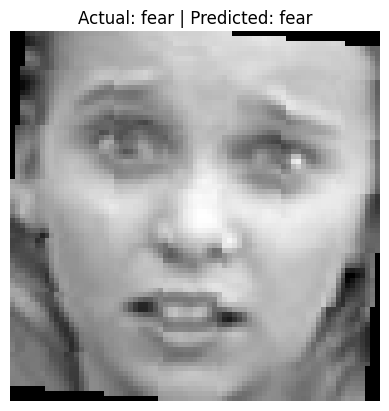

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


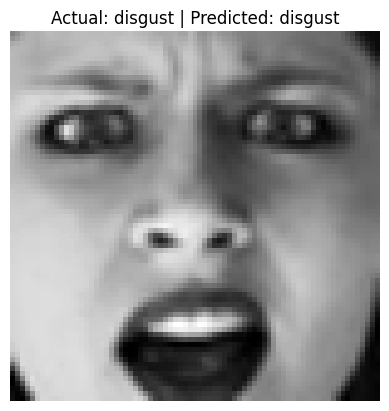

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step


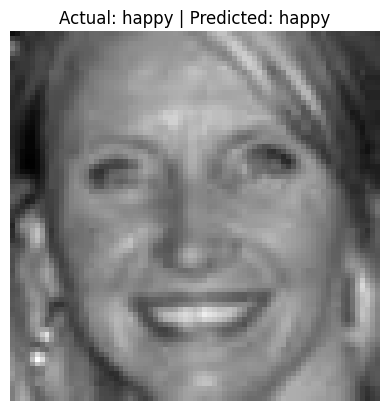

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step


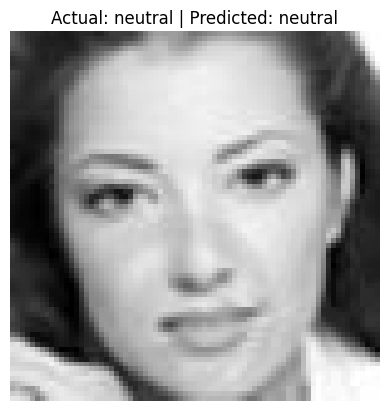

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


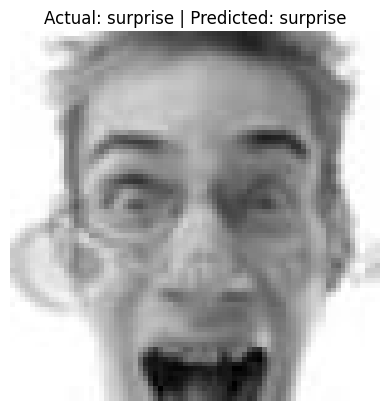

In [12]:
emotions = list(train_data.class_indices.keys())

for i in range(5):
    folder = random.choice(os.listdir(test_dir))
    path = os.path.join(test_dir, folder)
    img_name = random.choice(os.listdir(path))
    img_path = os.path.join(path, img_name)

    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img_resized = cv2.resize(img, (48,48))
    img_norm = img_resized / 255.0
    img_input = img_norm.reshape(1,48,48,1)

    pred = model.predict(img_input)
    predicted = emotions[np.argmax(pred)]

    plt.imshow(img, cmap='gray')
    plt.title(f"Actual: {folder} | Predicted: {predicted}")
    plt.axis('off')
    plt.show()